### **Business Understanding**

Problem       
Company Management ask me:   
What factors are influencing overall revenue performance?

What drives revenue in e-commerce?   
Revenue = price * quantity 

Revenue is influenced by many things:   
1 - customer demand  
2 - product popularity   
3 - marketing channels    
4 - city markets   
5 - return


KPIS 

Total revenue  
Total orders  
Units sold   
Average order value  
Return rate   
Marketing cost   
Revenue by category   
Revenue by city   



### **Exploratory Data Analysis**

In [4]:
import pandas as pd
df = pd.read_csv('ecommerce_project_dataset.csv')
df

,order_id,date,customer_id,category,product,city,marketing_channel,units_sold,price,revenue,marketing_cost,returns
0,5000,2/2/2025,1017,Sports,Football,Islamabad,Facebook Ads,4,198,792,21,2
1,5001,3/17/2025,1134,Electronics,Keyboard,Faisalabad,Organic,4,163,652,32,1
2,5002,3/16/2025,1038,Sports,Dumbbells,Lahore,Email,7,162,1134,74,2
3,5003,5/22/2025,1093,Clothing,Jeans,Multan,Organic,1,275,275,29,2
4,5004,5/7/2025,1035,Electronics,Laptop,Islamabad,Instagram,5,255,1275,42,1
...,...,...,...,...,...,...,...,...,...,...,...,...
495,5495,5/14/2025,1123,Home,Table,Faisalabad,Email,4,277,1108,39,1
496,5496,5/14/2025,1114,Beauty,Shampoo,Islamabad,Instagram,6,22,132,46,1
497,5497,5/10/2025,1010,Sports,Yoga Mat,Islamabad,Google Ads,8,64,512,60,1
498,5498,4/21/2025,1062,Beauty,Perfume,Multan,Facebook Ads,5,157,785,27,2


In [5]:
df.info

<bound method DataFrame.info of      order_id       date  customer_id     category    product        city  \
0        5000   2/2/2025         1017       Sports   Football   Islamabad   
1        5001  3/17/2025         1134  Electronics   Keyboard  Faisalabad   
2        5002  3/16/2025         1038       Sports  Dumbbells      Lahore   
3        5003  5/22/2025         1093     Clothing      Jeans      Multan   
4        5004   5/7/2025         1035  Electronics     Laptop   Islamabad   
..        ...        ...          ...          ...        ...         ...   
495      5495  5/14/2025         1123         Home      Table  Faisalabad   
496      5496  5/14/2025         1114       Beauty    Shampoo   Islamabad   
497      5497  5/10/2025         1010       Sports   Yoga Mat   Islamabad   
498      5498  4/21/2025         1062       Beauty    Perfume      Multan   
499      5499  6/19/2025         1169     Clothing      Shoes      Lahore   

    marketing_channel  units_sold  price  r

In [6]:
df.describe()

,order_id,customer_id,units_sold,price,revenue,marketing_cost,returns
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5249.500000,1103.754000,4.476000,164.568000,722.618000,42.762000,1.034000
std,144.481833,56.949029,2.274152,84.356395,538.465983,21.595789,0.808797
min,5000.000000,1000.000000,1.000000,20.000000,25.000000,5.000000,0.000000
25%,5124.750000,1055.000000,3.000000,89.000000,271.500000,25.000000,0.000000
50%,5249.500000,1109.500000,4.500000,163.000000,570.000000,42.000000,1.000000
75%,5374.250000,1150.250000,6.000000,236.500000,1104.000000,62.000000,2.000000
max,5499.000000,1200.000000,8.000000,300.000000,2352.000000,80.000000,2.000000


In [15]:
df.dtypes

order_id              int64
date                 object
customer_id           int64
category             object
product              object
city                 object
marketing_channel    object
units_sold            int64
price                 int64
revenue               int64
marketing_cost        int64
returns               int64
dtype: object

In [14]:
df.isnull().sum()

order_id             0
date                 0
customer_id          0
category             0
product              0
city                 0
marketing_channel    0
units_sold           0
price                0
revenue              0
marketing_cost       0
returns              0
dtype: int64

In [16]:
print("Unique products : ", df['product'].unique(),"\n")
print("Unique cities : ", df['city'].unique(), "\n")
print("Number of Unique Customers:", df['customer_id'].nunique(), "\n")

Unique products :  ['Football' 'Keyboard' 'Dumbbells' 'Jeans' 'Laptop' 'Lamp' 'Shampoo'
 'Sofa' 'Headphones' 'Perfume' 'Yoga Mat' 'Running Shoes' 'Jacket'
 'Smartphone' 'Face Cream' 'T-Shirt' 'Lipstick' 'Chair' 'Shoes' 'Table'] 

Unique cities :  ['Islamabad' 'Faisalabad' 'Lahore' 'Multan' 'Karachi'] 

Number of Unique Customers: 182 



In [13]:
df.shape

(500, 12)

Revenue analysis

In [17]:
# Which categories generate the most revenue?
df.groupby('category')['revenue'].sum().sort_values(ascending=False)

category
Beauty         84750
Sports         74427
Home           70200
Electronics    66367
Clothing       65565
Name: revenue, dtype: int64

In [18]:
#Which cities contribute the most revenue?
df.groupby('city')['revenue'].sum().sort_values(ascending=False)

city
Multan        76689
Islamabad     76310
Faisalabad    73627
Karachi       67488
Lahore        67195
Name: revenue, dtype: int64

In [19]:
#Which products sell the most?
df.groupby('product')['revenue'].sum().sort_values(ascending=False)

product
Lipstick         25735
Lamp             24066
Running Shoes    23823
Perfume          23248
Laptop           22847
Chair            22597
Shoes            21357
T-Shirt          20708
Shampoo          18552
Football         18394
Face Cream       17215
Yoga Mat         16673
Headphones       15843
Dumbbells        15537
Keyboard         14382
Jacket           14123
Smartphone       13295
Sofa             11827
Table            11710
Jeans             9377
Name: revenue, dtype: int64

Customer Behavior

In [31]:
# How many repeat customers exist?
customers_order_count = df['customer_id'].value_counts()
customers_repeat_count = customers_order_count[customers_order_count > 1]
customers_repeat_count.shape[0]

133

In [35]:
#Which customers spend the most?
customers_spend = df.groupby(['customer_id','city'])['revenue'].sum().sort_values(ascending=False)
customers_spend.head(5)

customer_id  city      
1035         Islamabad     3702
1097         Faisalabad    3675
1091         Multan        3296
1158         Karachi       3277
1172         Multan        3213
Name: revenue, dtype: int64

Marketing performance

In [36]:
#Which marketing channels generate the most revenue?
df.groupby('marketing_channel')['revenue'].sum().sort_values(ascending=False)

marketing_channel
Instagram       82579
Organic         82188
Facebook Ads    69109
Email           65464
Google Ads      61969
Name: revenue, dtype: int64

In [39]:
#Which channels cost the most?
costly_channel = df.groupby(['marketing_channel','marketing_cost'])['revenue'].sum().sort_values(ascending=False)
costly_channel.head(5)

marketing_channel  marketing_cost
Organic            36                4967
Email              68                4538
Organic            12                4242
Instagram          7                 4215
Organic            29                4143
Name: revenue, dtype: int64

Return analysis

In [52]:
#Which products have the highest return rate?
product_stats = df.groupby('product').agg({
    'units_sold': 'sum',
    'returns': 'sum'
}).reset_index()

# Calculate return rate
product_stats['return_rate'] = product_stats['returns'] / product_stats['units_sold'] *100

# Sort products by return rate descending
product_stats_sorted = product_stats.sort_values(by='return_rate', ascending=False)

# Display top 5 products with highest return rate
print(product_stats_sorted.head())

     product  units_sold  returns  return_rate
6      Jeans          82       30    36.585366
9     Laptop         122       37    30.327869
17   T-Shirt         107       27    25.233645
14     Shoes         127       32    25.196850
3   Football         116       29    25.000000


###  **Pattern Anlaysis**

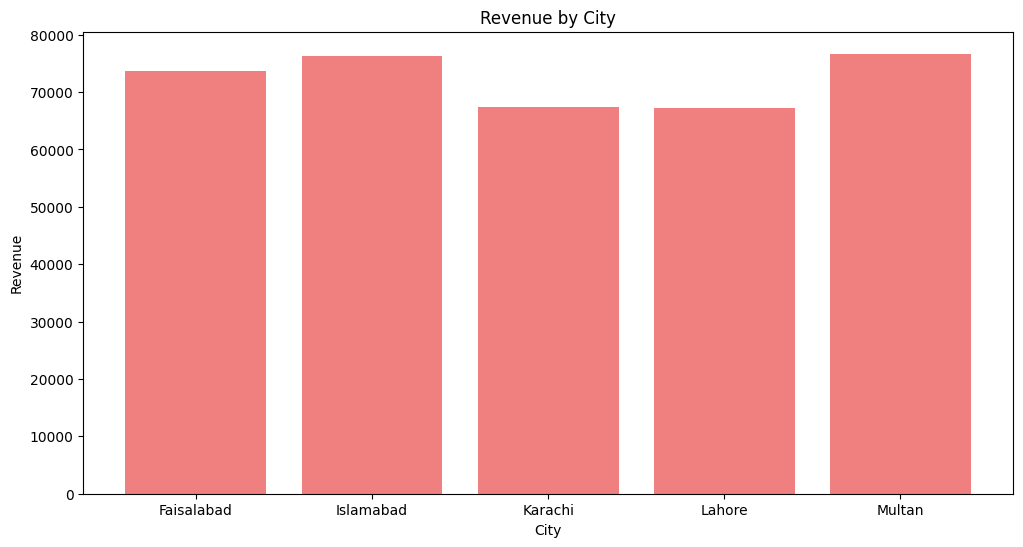

In [53]:
import matplotlib.pyplot as plt
city_revenue = df.groupby('city')['revenue'].sum()
plt.figure(figsize=(12,6))
plt.bar(city_revenue.index, city_revenue.values, color='lightcoral')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Revenue by City')
plt.show()

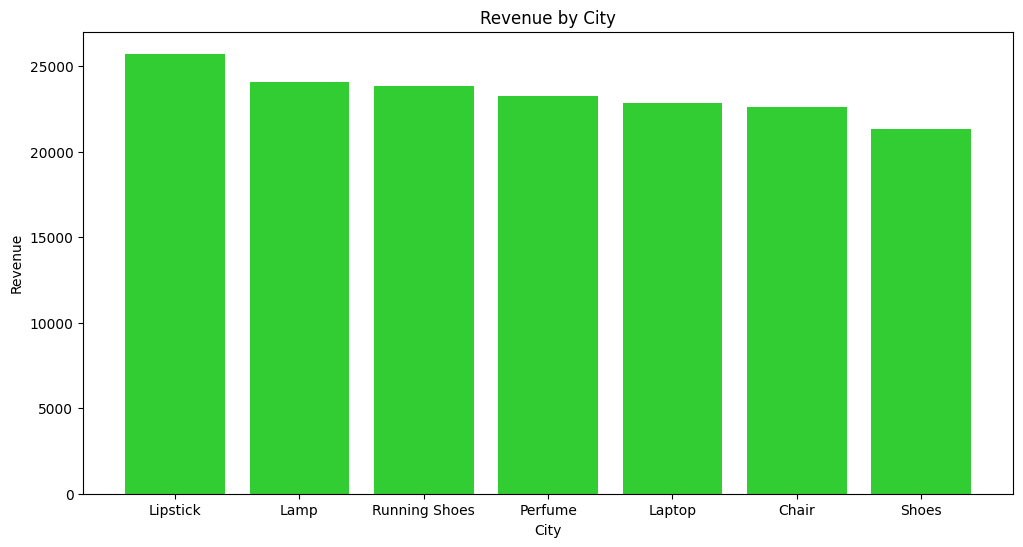

In [56]:
product_revenue = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(7)
plt.figure(figsize=(12,6))
plt.bar(product_revenue.index, product_revenue.values, color='limegreen')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Revenue by City')
plt.show()

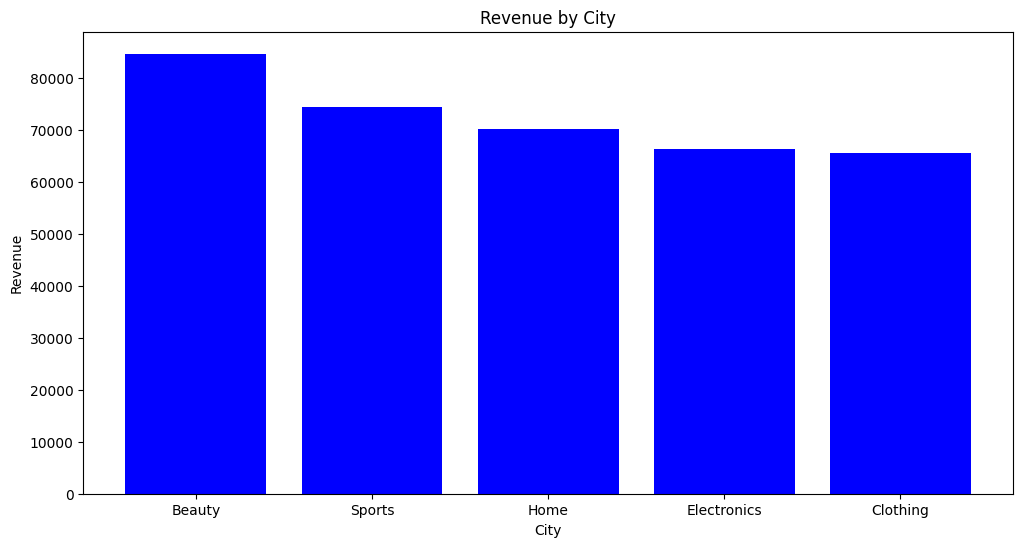

In [57]:
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(category_revenue.index, category_revenue.values, color='blue')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Revenue by City')
plt.show()

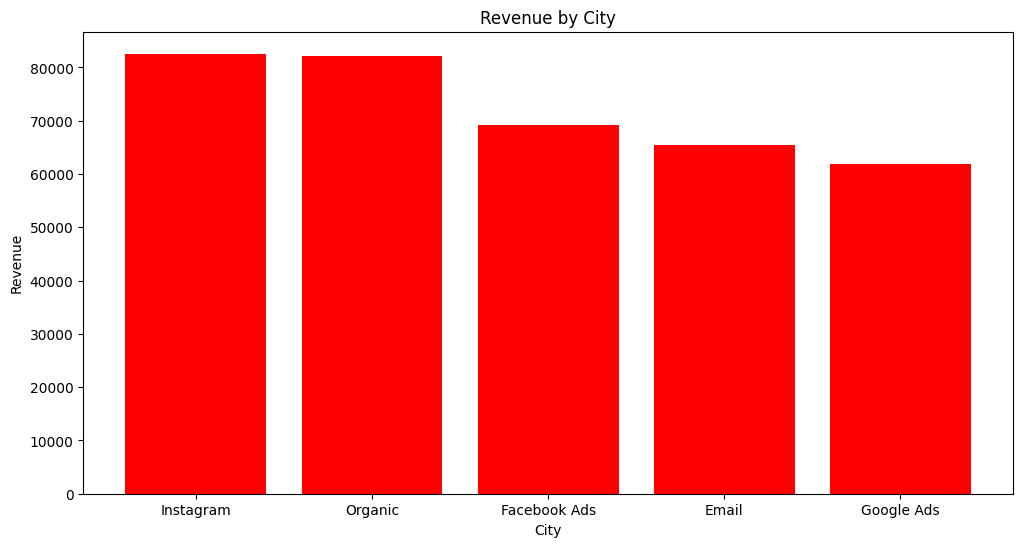

In [58]:
marketing_channel_revenue = df.groupby('marketing_channel')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(marketing_channel_revenue.index, marketing_channel_revenue.values, color='red')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Revenue by City')
plt.show()

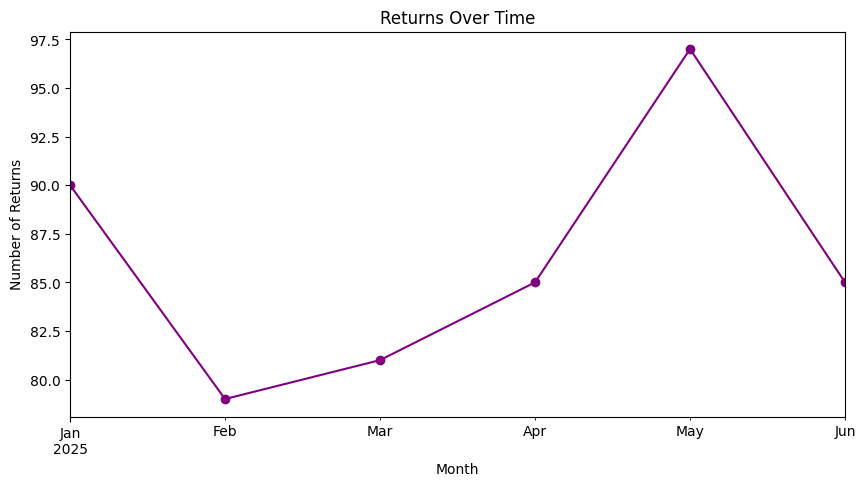

In [68]:
df['month'] = pd.to_datetime(df['date']).dt.to_period('M')
returns_over_time = df.groupby('month')['returns'].sum()

plt.figure(figsize=(10,5))
returns_over_time.plot(marker='o', linestyle='-', color='purple')
plt.title("Returns Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Returns")
plt.show()

In [71]:
avg_order_value = df['revenue'].sum() / df['order_id'].sum() * 100
avg_order_value

np.float64(13.76546337746452)

**********************************      **Insights**     ******************************************

### **Problem**
Company Management ask me:   
What factors are influencing overall revenue performance?


### **Key Findings:**    

1 - Beauty is the category which drive the most revenue       

2 - Multan city contributes more in generating high revenue.    

3 - 13.76 average order value per product.      

4 - 133 total customers who purchase reapeatedly different products.   

5 - Instagram is one of the marketing channel which helped in generating the most revenue.   

6 - Jeans has the highest return rate which is 36% approxiamtely.     

### **Recommendations:**  

1 - Company should focus on beauty products and their marketing on different channels for maximize sales.   

2 - Multan performs well; analyze why other cities, like Lahore, are underperforming.       
Investigate product issues, delivery challenges, or customer preferences in lower-performing cities to increase revenue.     

3 - 133 customers purchase repeatedly.Company should retain them.Focus on improving customer service and providing reliable products to the 133 repeat buyers.Loyalty programs or personalized promotions can help strengthen trust and drive more sales.     

4 - Jeans has the lowest revenue and its return rate is high.  
Identify quality issues or sizing problems and improve the product to reduce returns and increase profitability.

